## RoBERTa for SI

In [20]:
!git clone https://github.com/vrdn-23/SemEval-2020

fatal: destination path 'SemEval-2020' already exists and is not an empty directory.


In [21]:
from pathlib import Path

base_path = Path("SemEval-2020/datasets")

articles_path = base_path / "train-articles"
si_labels_path = base_path / "train-labels-task1-span-identification"
tc_labels_path = base_path / "train-labels-task2-technique-classification"

In [22]:
articles = {}

for txt in articles_path.glob("*.txt"):
    article_id = txt.stem.replace("article", "")
    articles[article_id] = txt.read_text(encoding="utf-8")

print(f"Статей: {len(articles)}")

Статей: 371


In [ ]:
si_labels = {}

for label in si_labels_path.glob("*.labels"):
    article_id = label.stem.replace("article", "").replace(".task1-SI", "")
    spans = []

    for line in label.read_text(encoding="utf-8").splitlines():
        _, start, end = line.split("\t")
        spans.append((int(start), int(end)))

    si_labels[article_id] = spans

print(next(iter(si_labels.items())))

In [25]:
from transformers import AutoTokenizer
import torch
from torch.utils.data import Dataset

MODEL_NAME = "roberta-large"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

In [26]:
class BertSpanDataset(Dataset):
    def __init__(self, articles, si_labels, tokenizer, max_len=512):
        self.samples = []
        self.tokenizer = tokenizer
        self.max_len = max_len

        for article_id, text in articles.items():
            spans = si_labels.get(article_id, [])

            encoding = tokenizer(
                text,
                return_offsets_mapping=True,
                truncation=True,
                max_length=max_len,
                padding="max_length"
            )

            offsets = encoding["offset_mapping"]
            labels = []

            for start, end in offsets:
                if start == end:
                    labels.append(-100)
                    continue

                label = 0  # O
                for span_start, span_end in spans:
                    if start >= span_start and start < span_end:
                        if start == span_start:
                            label = 1  # B
                        else:
                            label = 2  # I
                        break

                labels.append(label)

            encoding["labels"] = labels
            self.samples.append({k: torch.tensor(v) for k, v in encoding.items()})

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        return self.samples[idx]

In [27]:
from sklearn.model_selection import train_test_split

train_ids, test_ids = train_test_split(list(articles.keys()), test_size=0.2, random_state=42)

train_articles = {k: articles[k] for k in train_ids}
test_articles = {k: articles[k] for k in test_ids}

train_labels = {k: si_labels.get(k, []) for k in train_ids}
test_labels = {k: si_labels.get(k, []) for k in test_ids}

train_dataset = BertSpanDataset(train_articles, train_labels, tokenizer)
test_dataset = BertSpanDataset(test_articles, test_labels, tokenizer)

In [28]:
id2label = {
    0: "O",
    1: "B",
    2: "I"
}

def print_bert_example(dataset, tokenizer, idx=0, max_tokens=30):
    sample = dataset[idx]
    input_ids = sample["input_ids"]
    labels = sample["labels"]
    tokens = tokenizer.convert_ids_to_tokens(input_ids)
    printed = 0
    for token, label in zip(tokens, labels):
        label = label.item()
        if label == -100:
            continue
        print({
            "token": token,
            "label": id2label[label]
        })
        printed += 1
        if printed >= max_tokens:
            break
print_bert_example(train_dataset, tokenizer, idx=7)

{'token': 'Paul', 'label': 'O'}
{'token': 'ĠManafort', 'label': 'O'}
{'token': 'ĠSecret', 'label': 'O'}
{'token': 'ly', 'label': 'O'}
{'token': 'ĠMet', 'label': 'O'}
{'token': 'ĠWith', 'label': 'O'}
{'token': 'ĠJulian', 'label': 'O'}
{'token': 'ĠAssange', 'label': 'O'}
{'token': 'ĠShortly', 'label': 'O'}
{'token': 'ĠBefore', 'label': 'O'}
{'token': 'ĠJo', 'label': 'O'}
{'token': 'ining', 'label': 'O'}
{'token': 'ĠTrump', 'label': 'O'}
{'token': "'s", 'label': 'O'}
{'token': 'ĠPresidential', 'label': 'O'}
{'token': 'ĠCampaign', 'label': 'O'}
{'token': ':', 'label': 'O'}
{'token': 'ĠReport', 'label': 'O'}
{'token': 'Ċ', 'label': 'O'}
{'token': 'Ċ', 'label': 'O'}
{'token': 'A', 'label': 'O'}
{'token': 'ĠBritish', 'label': 'O'}
{'token': 'Ġnewspaper', 'label': 'O'}
{'token': 'Ġalleges', 'label': 'O'}
{'token': 'Ġthat', 'label': 'O'}
{'token': 'ĠPaul', 'label': 'O'}
{'token': 'ĠManafort', 'label': 'O'}
{'token': 'Ġsecretly', 'label': 'O'}
{'token': 'Ġmet', 'label': 'O'}
{'token': 'ĠWikiLeak

In [ ]:
from transformers import AutoModelForTokenClassification

model = AutoModelForTokenClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3
)

model = model.to("cuda")

In [30]:
import numpy as np

id2label = {0: "O", 1: "B", 2: "I"}

def bio_to_spans_from_logits(pred_ids):
    spans = []
    start = None

    for i, lab in enumerate(pred_ids):
        if lab == 1:
            if start is not None:
                spans.append((start, i))
            start = i
        elif lab == 2:
            if start is None:
                start = i
        else:
            if start is not None:
                spans.append((start, i))
                start = None

    if start is not None:
        spans.append((start, len(pred_ids)))

    return spans

In [31]:
def merge_spans(spans):
  if not spans:
    return []
  spans = sorted(spans, key=lambda x: x[0])
  merged = [spans[0]]
  for current in spans[1:]:
      prev_start, prev_end = merged[-1]
      curr_start, curr_end = current
      if curr_start <= prev_end:
          merged[-1] = (prev_start, max(prev_end, curr_end))
      else:
          merged.append(current)
  return merged

In [32]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    pred_labels = np.argmax(logits, axis=-1).flatten()
    labels = labels.flatten()
    mask = labels != -100
    pred_labels = pred_labels[mask]
    labels = labels[mask]
    acc = accuracy_score(labels, pred_labels)
    P, R, F1, _ = precision_recall_fscore_support(labels, pred_labels, average="macro", zero_division=0)
    return {"accuracy": acc, "P": P, "R": R, "F1": F1}

In [33]:
from transformers import Trainer, TrainingArguments

training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    num_train_epochs=5,
    weight_decay=0.01,
    logging_steps=50,
    save_strategy="no"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)

trainer.train()
trainer.evaluate()

Epoch,Training Loss,Validation Loss,Accuracy,P,R,F1
1,0.385762,0.309756,0.888801,0.519648,0.377490,0.390778
2,0.281070,0.310646,0.890588,0.642674,0.384094,0.403921
3,0.195141,0.323511,0.891240,0.606171,0.445443,0.483283
4,0.159538,0.344989,0.888545,0.604643,0.492724,0.529122
5,0.111454,0.373915,0.889765,0.601133,0.499054,0.535012


{'eval_loss': 0.3739146888256073,
 'eval_accuracy': 0.88976511970952,
 'eval_P': 0.6011330383624757,
 'eval_R': 0.4990539539515784,
 'eval_F1': 0.535012377053888,
 'eval_runtime': 7.9566,
 'eval_samples_per_second': 9.426,
 'eval_steps_per_second': 2.388,
 'epoch': 5.0}

In [34]:
import pandas as pd

log_history = trainer.state.log_history
df = pd.DataFrame(log_history)

# train loss
train_df = df[df["loss"].notna()]

# eval метрики
eval_df = df[df["eval_loss"].notna()]
print(eval_df.columns)

Index(['loss', 'grad_norm', 'learning_rate', 'epoch', 'step', 'eval_loss',
       'eval_accuracy', 'eval_P', 'eval_R', 'eval_F1', 'eval_runtime',
       'eval_samples_per_second', 'eval_steps_per_second', 'train_runtime',
       'train_samples_per_second', 'train_steps_per_second', 'total_flos',
       'train_loss'],
      dtype='object')


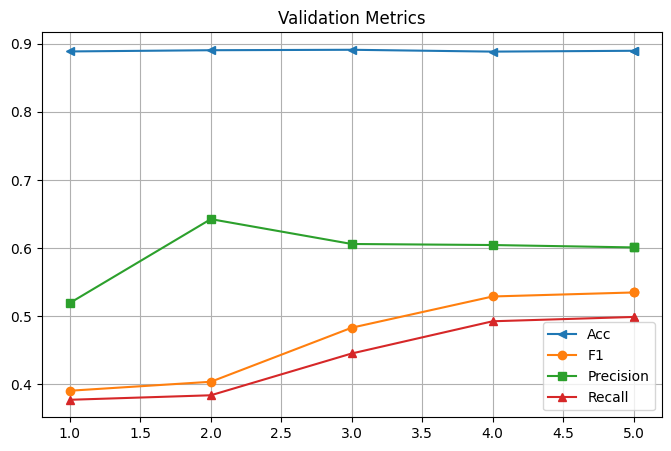

In [36]:
plt.figure(figsize=(8, 5))

plt.plot(eval_df["epoch"], eval_df["eval_accuracy"], marker='<', label="Acc")
plt.plot(eval_df["epoch"], eval_df["eval_F1"], marker='o', label="F1")
plt.plot(eval_df["epoch"], eval_df["eval_P"], marker='s', label="Precision")
plt.plot(eval_df["epoch"], eval_df["eval_R"], marker='^', label="Recall")

plt.grid(True)
plt.legend()
plt.title("Validation Metrics")

plt.show()

In [37]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

predictions = trainer.predict(test_dataset)
y_pred = np.argmax(predictions.predictions, axis=2)
y_true = predictions.label_ids

y_pred = y_pred.flatten()
y_true = y_true.flatten()

mask = y_true != -100
y_pred = y_pred[mask]
y_true = y_true[mask]

cm = confusion_matrix(y_true, y_pred)
print(cm)

[[29959   104   988]
 [  302    79    60]
 [ 2373    59  1328]]


In [38]:
print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.92      0.96      0.94     31051
           1       0.33      0.18      0.23       441
           2       0.56      0.35      0.43      3760

    accuracy                           0.89     35252
   macro avg       0.60      0.50      0.54     35252
weighted avg       0.87      0.89      0.88     35252

